# Frozen vs Evolving NTK (target no k=0,1,2; tracked k=0..6)

This notebook inspects `ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512`.

It:
- plots mode decay only for modes present in the target decomposition,
- tracks alignment/spectral geometry for all frequencies up to the target max K,
- shows eigenspace alignment via RMS-cos per plane,
- shows spectral strength per plane over training.


In [54]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from utils.artifacts_io import latest_run_dir, load_manifest, npz


In [55]:
BASE = "../results"
EXP_NAME = "ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512"

plot_path = Path("plots") / EXP_NAME
plot_path.mkdir(parents=True, exist_ok=True)
print("Plots will be saved to:", plot_path)

run_dir = latest_run_dir(BASE, EXP_NAME)
if run_dir is None:
    raise FileNotFoundError(f"No run found for experiment '{EXP_NAME}' in {BASE}")

manifest = load_manifest(run_dir)
width_key = sorted(int(w) for w in manifest["runs"].keys())[0]
run_file = manifest["runs"][str(width_key)]
arr = npz(run_dir, run_file)

print("Loaded run dir:", run_dir)
print("run file:", run_file)
print("target_Ks:", manifest["meta"]["target_Ks"])
print("tracked_freqs:", manifest["meta"]["tracked_freqs"])
print("plane_freqs:", manifest["meta"]["plane_freqs"])
print("full_target_freqs:", manifest["meta"]["full_target_freqs"])
print("seeds:", manifest["meta"]["seeds"])
print("snapshot count:", len(manifest["meta"]["snapshot_steps"]))


Plots will be saved to: plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512
Loaded run dir: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/results/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/20260531-181300-b30ab08b
run file: runs/width_128.npz
target_Ks: [3, 4, 5, 6]
tracked_freqs: [0, 1, 2, 3, 4, 5, 6]
plane_freqs: [0, 1, 2, 3, 4, 5, 6]
full_target_freqs: [0, 1, 2, 3, 4, 5, 6]
seeds: [0]
snapshot count: 201


In [56]:
seeds = np.asarray(arr["seeds"], dtype=int)
steps = np.asarray(arr["snapshot_steps"], dtype=int)
tracked_freqs = np.asarray(arr["tracked_freqs"], dtype=int)
plane_freqs = np.asarray(arr["plane_freqs"], dtype=int)

tracked_mode_names = [str(x) if not isinstance(x, bytes) else x.decode("utf-8") for x in arr["tracked_mode_names"]]
tracked_mode_freqs = np.asarray(arr["tracked_mode_freqs"], dtype=int)
tracked_mode_types = [str(x) if not isinstance(x, bytes) else x.decode("utf-8") for x in arr["tracked_mode_types"]]

mse_frozen = np.asarray(arr["train_mse_frozen"], dtype=float)
mse_evolving = np.asarray(arr["train_mse_evolving"], dtype=float)
proj_frozen = np.asarray(arr["mode_proj_frozen"], dtype=float)
proj_evolving = np.asarray(arr["mode_proj_evolving"], dtype=float)

plane_angles_frozen = np.asarray(arr["plane_angles_frozen"], dtype=float)
plane_angles_evolving = np.asarray(arr["plane_angles_evolving"], dtype=float)
plane_eigvals_frozen = np.asarray(arr["plane_eigvals_frozen"], dtype=float)
plane_eigvals_evolving = np.asarray(arr["plane_eigvals_evolving"], dtype=float)

print("tracked mode names:", tracked_mode_names)
print("tracked mode freqs:", tracked_mode_freqs)
print("tracked mode types:", tracked_mode_types)
print("mode_proj_frozen shape:", proj_frozen.shape)
print("plane_angles_frozen shape:", plane_angles_frozen.shape)
print("plane_eigvals_frozen shape:", plane_eigvals_frozen.shape)


tracked mode names: ['const', 'cos_1', 'sin_1', 'cos_2', 'sin_2', 'cos_3', 'sin_3', 'cos_4', 'sin_4', 'cos_5', 'sin_5', 'cos_6', 'sin_6']
tracked mode freqs: [0 1 1 2 2 3 3 4 4 5 5 6 6]
tracked mode types: ['const', 'cos', 'sin', 'cos', 'sin', 'cos', 'sin', 'cos', 'sin', 'cos', 'sin', 'cos', 'sin']
mode_proj_frozen shape: (1, 201, 13)
plane_angles_frozen shape: (1, 201, 7, 2)
plane_eigvals_frozen shape: (1, 201, 7, 2)


In [57]:
def target_present_mode_names(target_Ks, target_amps, target_phases, amp_tol=1e-10):
    present = []
    for k, a, phi in zip(target_Ks, target_amps, target_phases):
        k = int(k)
        a = float(a)
        phi = float(phi)

        if k == 0:
            c0 = a * np.cos(phi)
            if abs(c0) > amp_tol and "const" not in present:
                present.append("const")
            continue

        c_cos = a * np.cos(phi)
        c_sin = -a * np.sin(phi)
        if abs(c_cos) > amp_tol:
            present.append(f"cos_{k}")
        if abs(c_sin) > amp_tol:
            present.append(f"sin_{k}")

    out = []
    seen = set()
    for m in present:
        if m not in seen:
            out.append(m)
            seen.add(m)
    return out


target_Ks = np.asarray(manifest["meta"]["target_Ks"], dtype=int)
target_amps = np.asarray(manifest["meta"]["target_amps"], dtype=float)
target_phases = np.asarray(manifest["meta"]["target_phases"], dtype=float)

present_modes = target_present_mode_names(target_Ks, target_amps, target_phases)
tracked_mode_set = set(tracked_mode_names)
modes_to_plot = [m for m in present_modes if m in tracked_mode_set]

missing_from_tracking = sorted(set(present_modes) - tracked_mode_set)
untracked_freqs = sorted(set(int(k) for k in manifest["meta"]["full_target_freqs"]) - set(int(k) for k in tracked_freqs))

print("target-present modes:", present_modes)
print("tracked-present modes used for plots:", modes_to_plot)
if missing_from_tracking:
    print("present but not tracked:", missing_from_tracking)
print("frequencies not tracked in this run:", untracked_freqs)


target-present modes: ['cos_3', 'cos_4', 'sin_5', 'sin_6']
tracked-present modes used for plots: ['cos_3', 'cos_4', 'sin_5', 'sin_6']
frequencies not tracked in this run: []


Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/train_mse_frozen_vs_evolving.png


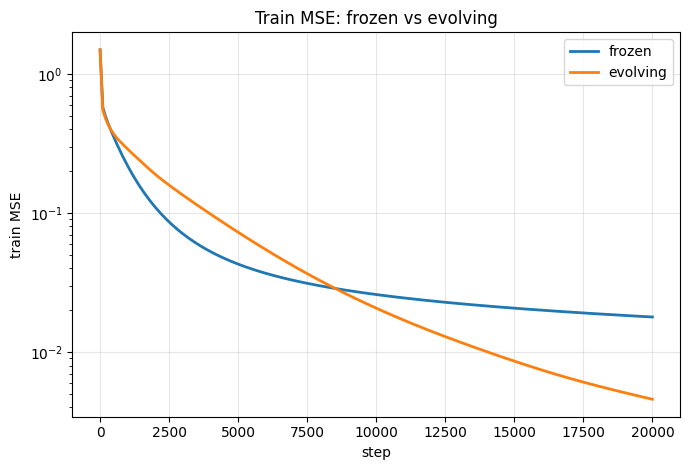

In [58]:
plt.figure(figsize=(7.0, 4.8))

mse_frozen_mean = mse_frozen.mean(axis=0)
mse_frozen_std = mse_frozen.std(axis=0)
mse_evolving_mean = mse_evolving.mean(axis=0)
mse_evolving_std = mse_evolving.std(axis=0)

plt.plot(steps, mse_frozen_mean, linewidth=2, label="frozen")
plt.fill_between(steps, mse_frozen_mean - mse_frozen_std, mse_frozen_mean + mse_frozen_std, alpha=0.2)

plt.plot(steps, mse_evolving_mean, linewidth=2, label="evolving")
plt.fill_between(steps, mse_evolving_mean - mse_evolving_std, mse_evolving_mean + mse_evolving_std, alpha=0.2)

plt.yscale("log")
plt.xlabel("step")
plt.ylabel("train MSE")
plt.title("Train MSE: frozen vs evolving")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

filename = plot_path / "train_mse_frozen_vs_evolving.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
print(f"Successfully saved {filename}")
plt.show()


Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/target_present_mode_decay_frozen_vs_evolving_two_panel.png


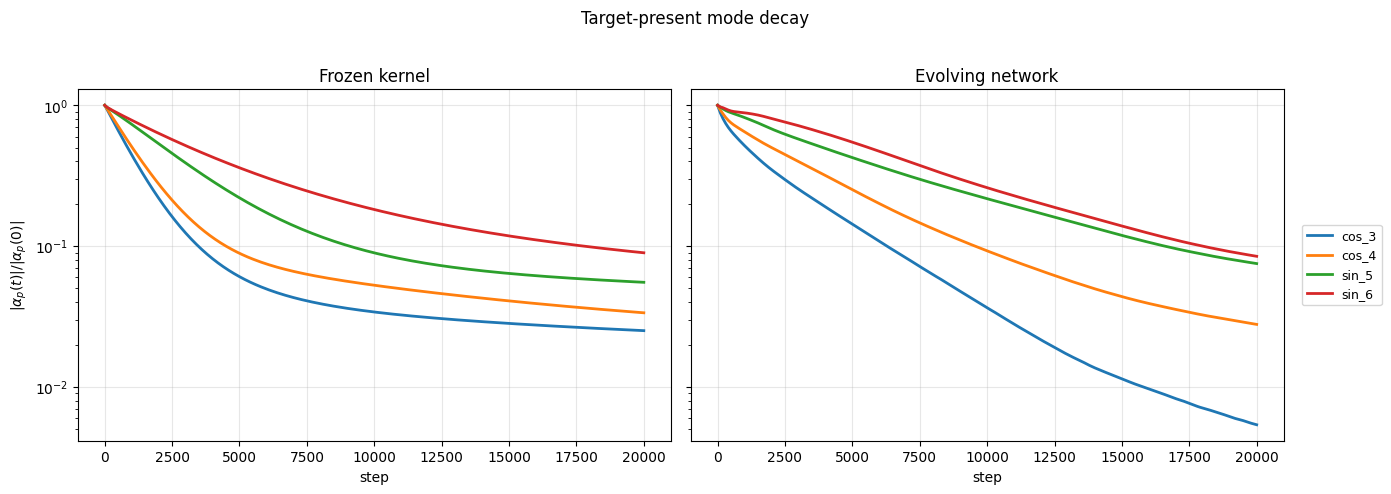

In [59]:
def normalize_abs_curves(mode_proj, eps=1e-12):
    denom = np.maximum(np.abs(mode_proj[:, 0:1, :]), eps)
    return np.abs(mode_proj) / denom

curves_frozen = normalize_abs_curves(proj_frozen)
curves_evolving = normalize_abs_curves(proj_evolving)

frozen_mean = curves_frozen.mean(axis=0)
frozen_std = curves_frozen.std(axis=0)
evolving_mean = curves_evolving.mean(axis=0)
evolving_std = curves_evolving.std(axis=0)

mode_to_idx = {m: i for i, m in enumerate(tracked_mode_names)}

fig, axes = plt.subplots(1, 2, figsize=(14.0, 4.8), sharex=True, sharey=True)
for mode_name in modes_to_plot:
    j = mode_to_idx[mode_name]

    axes[0].plot(steps, frozen_mean[:, j], linewidth=2, label=mode_name)
    axes[0].fill_between(steps, np.clip(frozen_mean[:, j] - frozen_std[:, j], 1e-10, None), np.clip(frozen_mean[:, j] + frozen_std[:, j], 1e-10, None), alpha=0.14)

    axes[1].plot(steps, evolving_mean[:, j], linewidth=2, label=mode_name)
    axes[1].fill_between(steps, np.clip(evolving_mean[:, j] - evolving_std[:, j], 1e-10, None), np.clip(evolving_mean[:, j] + evolving_std[:, j], 1e-10, None), alpha=0.14)

axes[0].set_yscale("log")
axes[0].set_xlabel("step")
axes[1].set_xlabel("step")
axes[0].set_ylabel(r"$|\alpha_p(t)| / |\alpha_p(0)|$")
axes[0].set_title("Frozen kernel")
axes[1].set_title("Evolving network")
axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)

fig.suptitle("Target-present mode decay", y=1.02)
fig.tight_layout()

filename = plot_path / "target_present_mode_decay_frozen_vs_evolving_two_panel.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
print(f"Successfully saved {filename}")
plt.show()


Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/mode_decay_cos_3_frozen_vs_evolving.png


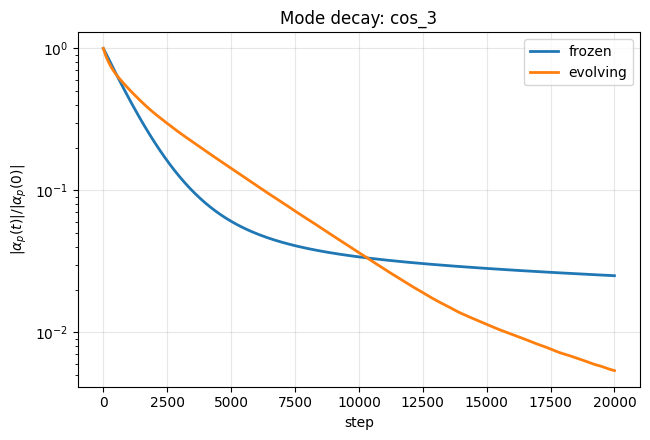

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/mode_decay_cos_4_frozen_vs_evolving.png


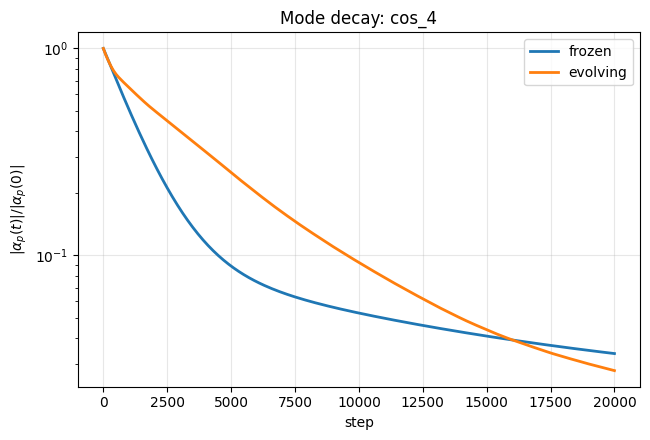

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/mode_decay_sin_5_frozen_vs_evolving.png


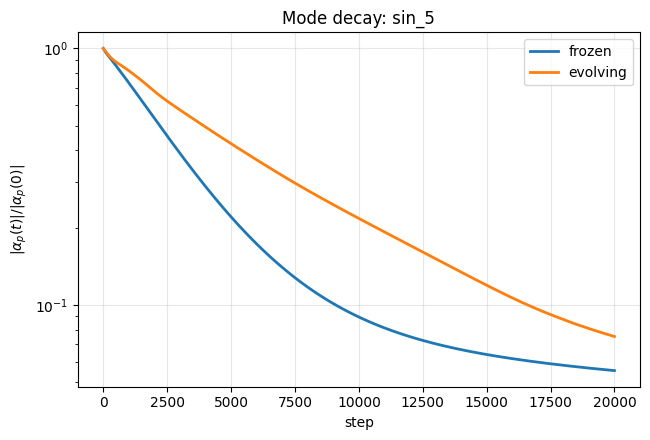

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/mode_decay_sin_6_frozen_vs_evolving.png


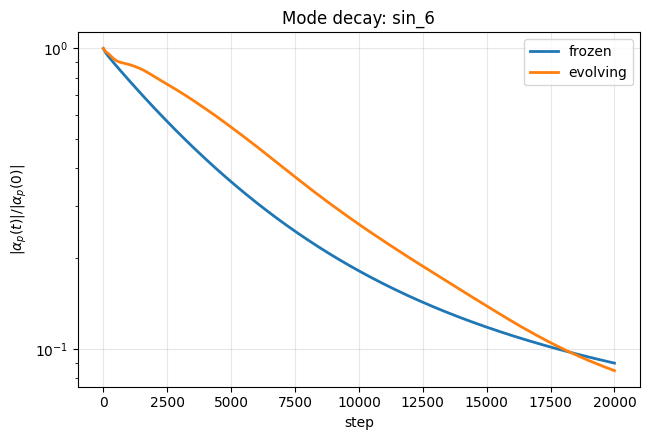

In [60]:
for mode_name in modes_to_plot:
    j = mode_to_idx[mode_name]

    plt.figure(figsize=(6.6, 4.5))
    plt.plot(steps, frozen_mean[:, j], linewidth=2, label="frozen")
    plt.fill_between(steps, np.clip(frozen_mean[:, j] - frozen_std[:, j], 1e-10, None), np.clip(frozen_mean[:, j] + frozen_std[:, j], 1e-10, None), alpha=0.18)

    plt.plot(steps, evolving_mean[:, j], linewidth=2, label="evolving")
    plt.fill_between(steps, np.clip(evolving_mean[:, j] - evolving_std[:, j], 1e-10, None), np.clip(evolving_mean[:, j] + evolving_std[:, j], 1e-10, None), alpha=0.18)

    plt.yscale("log")
    plt.xlabel("step")
    plt.ylabel(r"$|\alpha_p(t)| / |\alpha_p(0)|$")
    plt.title(f"Mode decay: {mode_name}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    filename = plot_path / f"mode_decay_{mode_name}_frozen_vs_evolving.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Successfully saved {filename}")
    plt.show()


Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/eigenspace_alignment_rms_cos_over_time.png


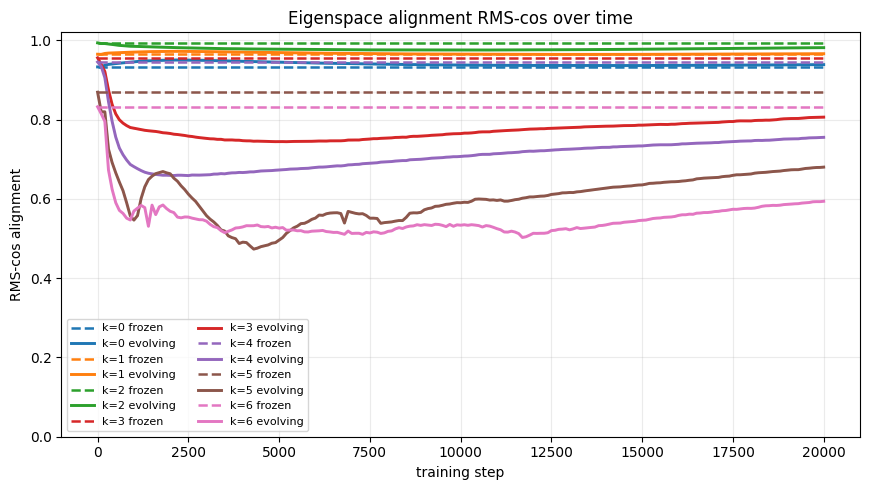

In [61]:
score_frozen = np.sqrt(np.nanmean(np.cos(plane_angles_frozen) ** 2, axis=3))
score_evolving = np.sqrt(np.nanmean(np.cos(plane_angles_evolving) ** 2, axis=3))

fig, ax = plt.subplots(1, 1, figsize=(8.8, 5.0))
for j, k in enumerate(plane_freqs):
    c = plt.cm.tab10(j % 10)
    mf = np.nanmean(score_frozen[:, :, j], axis=0)
    sf = np.nanstd(score_frozen[:, :, j], axis=0)
    me = np.nanmean(score_evolving[:, :, j], axis=0)
    se = np.nanstd(score_evolving[:, :, j], axis=0)

    ax.plot(steps, mf, '--', color=c, linewidth=1.8, label=f"k={int(k)} frozen")
    ax.fill_between(steps, np.clip(mf - sf, 0.0, 1.0), np.clip(mf + sf, 0.0, 1.0), color=c, alpha=0.08)

    ax.plot(steps, me, '-', color=c, linewidth=2.1, label=f"k={int(k)} evolving")
    ax.fill_between(steps, np.clip(me - se, 0.0, 1.0), np.clip(me + se, 0.0, 1.0), color=c, alpha=0.14)

ax.set_ylim(0.0, 1.02)
ax.set_xlabel("training step")
ax.set_ylabel("RMS-cos alignment")
ax.set_title("Eigenspace alignment RMS-cos over time")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, ncol=2)

fig.tight_layout()
filename = plot_path / "eigenspace_alignment_rms_cos_over_time.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
print(f"Successfully saved {filename}")
plt.show()


Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/spectral_strength_per_plane_over_time.png


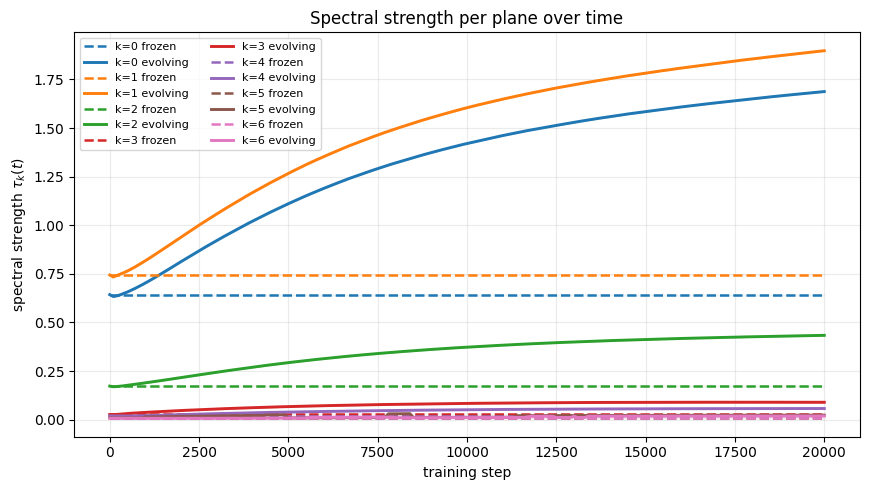

In [62]:
strength_frozen = np.nansum(plane_eigvals_frozen, axis=3)
strength_evolving = np.nansum(plane_eigvals_evolving, axis=3)
# strength_ratio = strength_evolving / np.maximum(strength_frozen, 1e-12)

fig, ax = plt.subplots(1, 1, figsize=(8.8, 5.0))
for j, k in enumerate(plane_freqs):
    c = plt.cm.tab10(j % 10)
    mf = np.nanmean(strength_frozen[:, :, j], axis=0)
    sf = np.nanstd(strength_frozen[:, :, j], axis=0)
    me = np.nanmean(strength_evolving[:, :, j], axis=0)
    se = np.nanstd(strength_evolving[:, :, j], axis=0)

    ax.plot(steps, mf, '--', color=c, linewidth=1.8, label=f"k={int(k)} frozen")
    ax.fill_between(steps, np.maximum(mf - sf, 0.0), mf + sf, color=c, alpha=0.08)

    ax.plot(steps, me, '-', color=c, linewidth=2.1, label=f"k={int(k)} evolving")
    ax.fill_between(steps, np.maximum(me - se, 0.0), me + se, color=c, alpha=0.14)

ax.set_xlabel("training step")
ax.set_ylabel(r"spectral strength $\tau_k(t)$")
ax.set_title("Spectral strength per plane over time")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, ncol=2)

fig.tight_layout()
filename = plot_path / "spectral_strength_per_plane_over_time.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
print(f"Successfully saved {filename}")
plt.show()

# fig, ax = plt.subplots(1, 1, figsize=(8.8, 5.0))
# for j, k in enumerate(plane_freqs):
#     c = plt.cm.tab10(j % 10)
#     mr = np.nanmean(strength_ratio[:, :, j], axis=0)
#     sr = np.nanstd(strength_ratio[:, :, j], axis=0)

#     ax.plot(steps, mr, '-', color=c, linewidth=2.0, label=f"k={int(k)}")
#     ax.fill_between(steps, np.maximum(mr - sr, 0.0), mr + sr, color=c, alpha=0.16)

# ax.axhline(1.0, color='0.4', linestyle='--', linewidth=1.1)
# ax.set_xlabel("training step")
# ax.set_ylabel(r"$\tau_k^{evolving}(t) / \tau_k^{frozen}(t)$")
# ax.set_title("Spectral strength redistribution ratio per plane")
# ax.grid(True, alpha=0.25)
# ax.legend(fontsize=8, ncol=2)

# fig.tight_layout()
# filename = plot_path / "spectral_strength_ratio_per_plane_over_time.png"
# plt.savefig(filename, dpi=300, bbox_inches="tight")
# print(f"Successfully saved {filename}")
# plt.show()


Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/eigenspace_alignment_rms_cos_over_time_k3plus.png


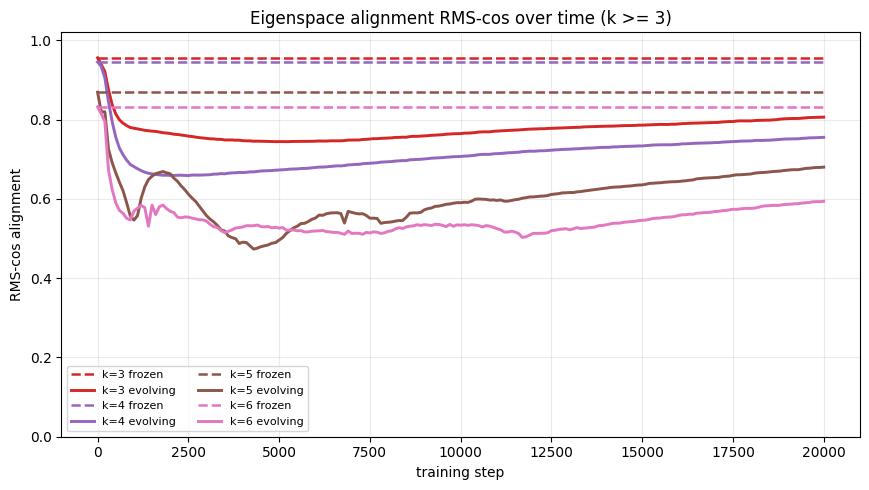

In [63]:
plane_freqs_k3 = [int(k) for k in plane_freqs if int(k) >= 3]
plane_freq_idx = {int(k): j for j, k in enumerate(plane_freqs)}

score_frozen = np.sqrt(np.nanmean(np.cos(plane_angles_frozen) ** 2, axis=3))
score_evolving = np.sqrt(np.nanmean(np.cos(plane_angles_evolving) ** 2, axis=3))

fig, ax = plt.subplots(1, 1, figsize=(8.8, 5.0))
for k in plane_freqs_k3:
    j = plane_freq_idx[int(k)]
    c = plt.cm.tab10(j % 10)

    mf = np.nanmean(score_frozen[:, :, j], axis=0)
    sf = np.nanstd(score_frozen[:, :, j], axis=0)
    me = np.nanmean(score_evolving[:, :, j], axis=0)
    se = np.nanstd(score_evolving[:, :, j], axis=0)

    ax.plot(steps, mf, '--', color=c, linewidth=1.8, label=f"k={int(k)} frozen")
    ax.fill_between(steps, np.clip(mf - sf, 0.0, 1.0), np.clip(mf + sf, 0.0, 1.0), color=c, alpha=0.08)

    ax.plot(steps, me, '-', color=c, linewidth=2.1, label=f"k={int(k)} evolving")
    ax.fill_between(steps, np.clip(me - se, 0.0, 1.0), np.clip(me + se, 0.0, 1.0), color=c, alpha=0.14)

ax.set_ylim(0.0, 1.02)
ax.set_xlabel("training step")
ax.set_ylabel("RMS-cos alignment")
ax.set_title("Eigenspace alignment RMS-cos over time (k >= 3)")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, ncol=2)

fig.tight_layout()
filename = plot_path / "eigenspace_alignment_rms_cos_over_time_k3plus.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
print(f"Successfully saved {filename}")
plt.show()


Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/spectral_strength_per_plane_over_time_k3plus.png


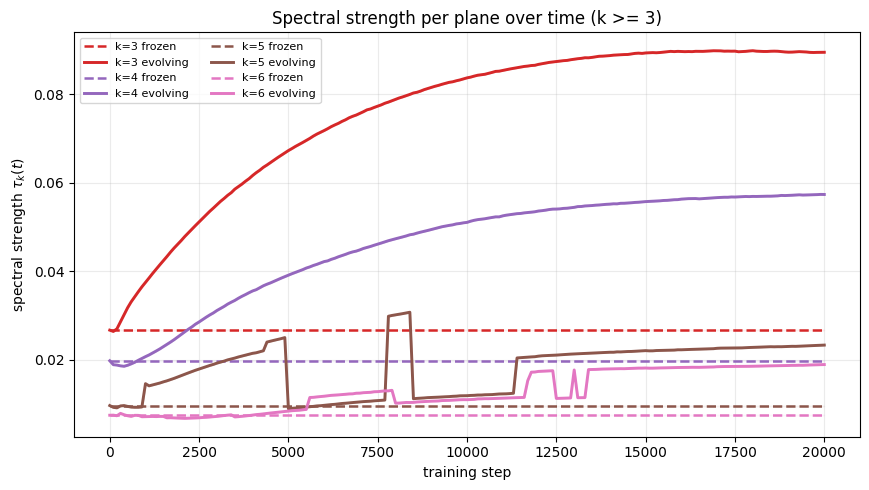

In [64]:
plane_freqs_k3 = [int(k) for k in plane_freqs if int(k) >= 3]
plane_freq_idx = {int(k): j for j, k in enumerate(plane_freqs)}

strength_frozen = np.nansum(plane_eigvals_frozen, axis=3)
strength_evolving = np.nansum(plane_eigvals_evolving, axis=3)
# strength_ratio = strength_evolving / np.maximum(strength_frozen, 1e-12)

fig, ax = plt.subplots(1, 1, figsize=(8.8, 5.0))
for k in plane_freqs_k3:
    j = plane_freq_idx[int(k)]
    c = plt.cm.tab10(j % 10)
    mf = np.nanmean(strength_frozen[:, :, j], axis=0)
    sf = np.nanstd(strength_frozen[:, :, j], axis=0)
    me = np.nanmean(strength_evolving[:, :, j], axis=0)
    se = np.nanstd(strength_evolving[:, :, j], axis=0)

    ax.plot(steps, mf, '--', color=c, linewidth=1.8, label=f"k={int(k)} frozen")
    ax.fill_between(steps, np.maximum(mf - sf, 0.0), mf + sf, color=c, alpha=0.08)

    ax.plot(steps, me, '-', color=c, linewidth=2.1, label=f"k={int(k)} evolving")
    ax.fill_between(steps, np.maximum(me - se, 0.0), me + se, color=c, alpha=0.14)

ax.set_xlabel("training step")
ax.set_ylabel(r"spectral strength $\tau_k(t)$")
ax.set_title("Spectral strength per plane over time (k >= 3)")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, ncol=2)

fig.tight_layout()
filename = plot_path / "spectral_strength_per_plane_over_time_k3plus.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
print(f"Successfully saved {filename}")
plt.show()

# fig, ax = plt.subplots(1, 1, figsize=(8.8, 5.0))
# for k in plane_freqs_k3:
#     j = plane_freq_idx[int(k)]
#     c = plt.cm.tab10(j % 10)
#     mr = np.nanmean(strength_ratio[:, :, j], axis=0)
#     sr = np.nanstd(strength_ratio[:, :, j], axis=0)

#     ax.plot(steps, mr, '-', color=c, linewidth=2.0, label=f"k={int(k)}")
#     ax.fill_between(steps, np.maximum(mr - sr, 0.0), mr + sr, color=c, alpha=0.16)

# ax.axhline(1.0, color='0.4', linestyle='--', linewidth=1.1)
# ax.set_xlabel("training step")
# ax.set_ylabel(r"$\tau_k^{evolving}(t) / \tau_k^{frozen}(t)$")
# ax.set_title("Spectral strength redistribution ratio per plane (k >= 3)")
# ax.grid(True, alpha=0.25)
# ax.legend(fontsize=8, ncol=2)

# fig.tight_layout()
# filename = plot_path / "spectral_strength_ratio_per_plane_over_time_k3plus.png"
# plt.savefig(filename, dpi=300, bbox_inches="tight")
# print(f"Successfully saved {filename}")
# plt.show()


In [65]:
from matplotlib.lines import Line2D

EARLY_MAX_STEP_STACK = 2000
width_keys = sorted(int(w) for w in manifest["runs"].keys())
run_by_width = {w: npz(run_dir, manifest["runs"][str(w)]) for w in width_keys}

print("available widths in run:", width_keys)
if len(width_keys) == 0:
    raise ValueError("No widths found in manifest['runs'].")

plane_freqs_ref = np.asarray(run_by_width[width_keys[0]]["plane_freqs"], dtype=int)
freq_color = {int(k): plt.cm.tab10(i % 10) for i, k in enumerate(plane_freqs_ref)}
print("reference plane freqs for colors:", plane_freqs_ref.tolist())


available widths in run: [128, 256, 512, 1024]
reference plane freqs for colors: [0, 1, 2, 3, 4, 5, 6]


Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/train_mse_frozen_vs_evolving_w128.png


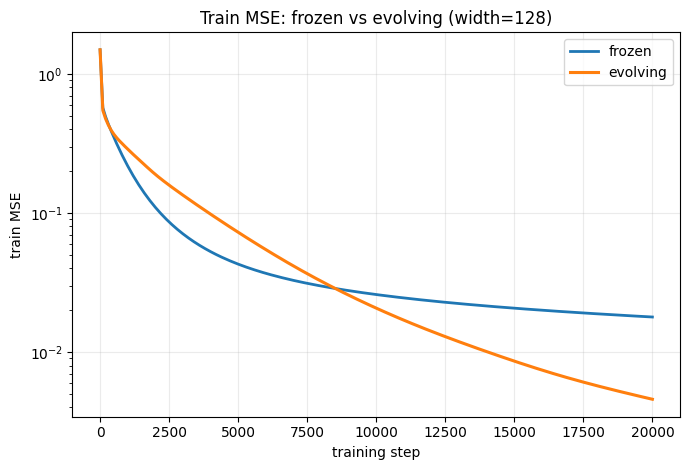

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/train_mse_frozen_vs_evolving_w256.png


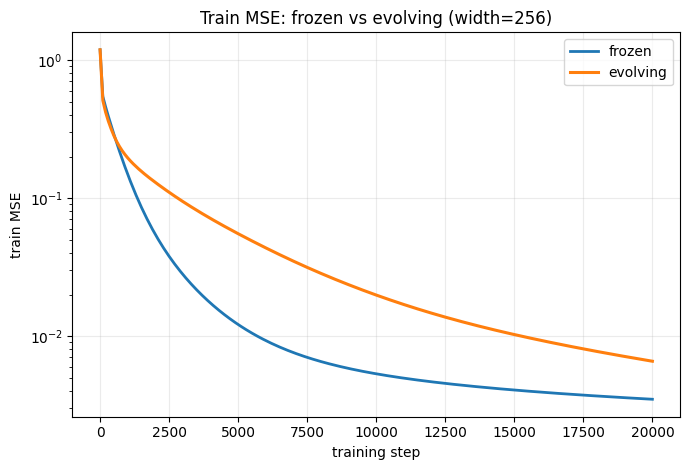

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/train_mse_frozen_vs_evolving_w512.png


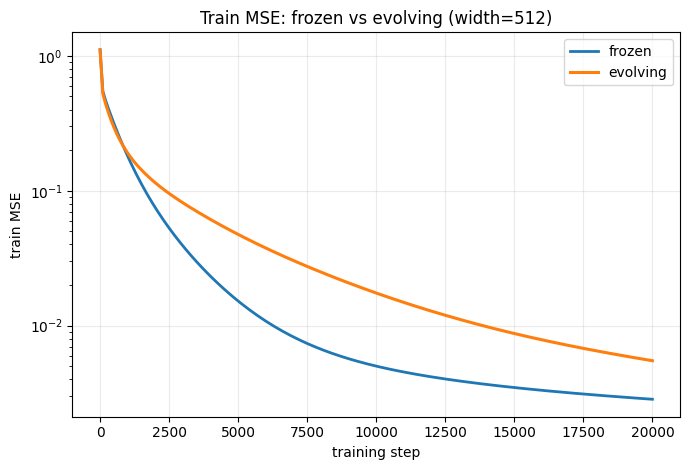

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/train_mse_frozen_vs_evolving_w1024.png


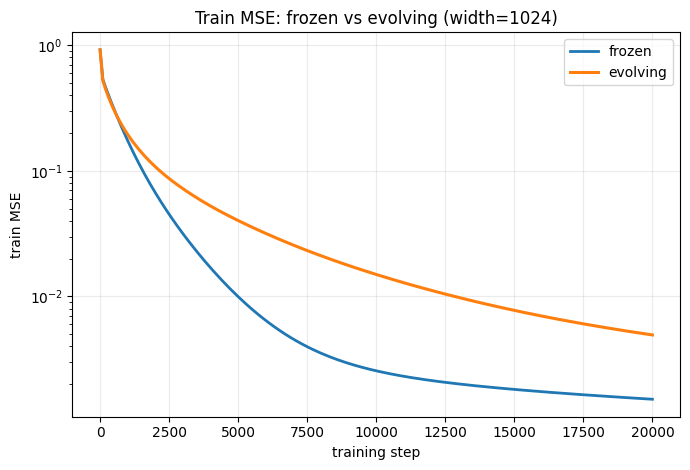

In [66]:
for w in width_keys:
    run_w = run_by_width[w]

    steps_w = np.asarray(run_w["snapshot_steps"], dtype=int)
    mse_f_w = np.asarray(run_w["train_mse_frozen"], dtype=float)
    mse_e_w = np.asarray(run_w["train_mse_evolving"], dtype=float)

    mf = np.nanmean(mse_f_w, axis=0)
    sf = np.nanstd(mse_f_w, axis=0)
    me = np.nanmean(mse_e_w, axis=0)
    se = np.nanstd(mse_e_w, axis=0)

    plt.figure(figsize=(7.0, 4.8))
    plt.plot(steps_w, mf, linewidth=2.0, label="frozen")
    plt.fill_between(steps_w, np.maximum(mf - sf, 1e-16), mf + sf, alpha=0.12)

    plt.plot(steps_w, me, linewidth=2.2, label="evolving")
    plt.fill_between(steps_w, np.maximum(me - se, 1e-16), me + se, alpha=0.16)

    plt.yscale("log")
    plt.xlabel("training step")
    plt.ylabel("train MSE")
    plt.title(f"Train MSE: frozen vs evolving (width={w})")
    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=10)
    plt.tight_layout()

    filename = plot_path / f"train_mse_frozen_vs_evolving_w{w}.png"
    plt.savefig(filename, bbox_inches="tight")
    print(f"Successfully saved {filename}")
    plt.show()


Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/rms_cos_alignment_by_freq_allfreq_w128.png


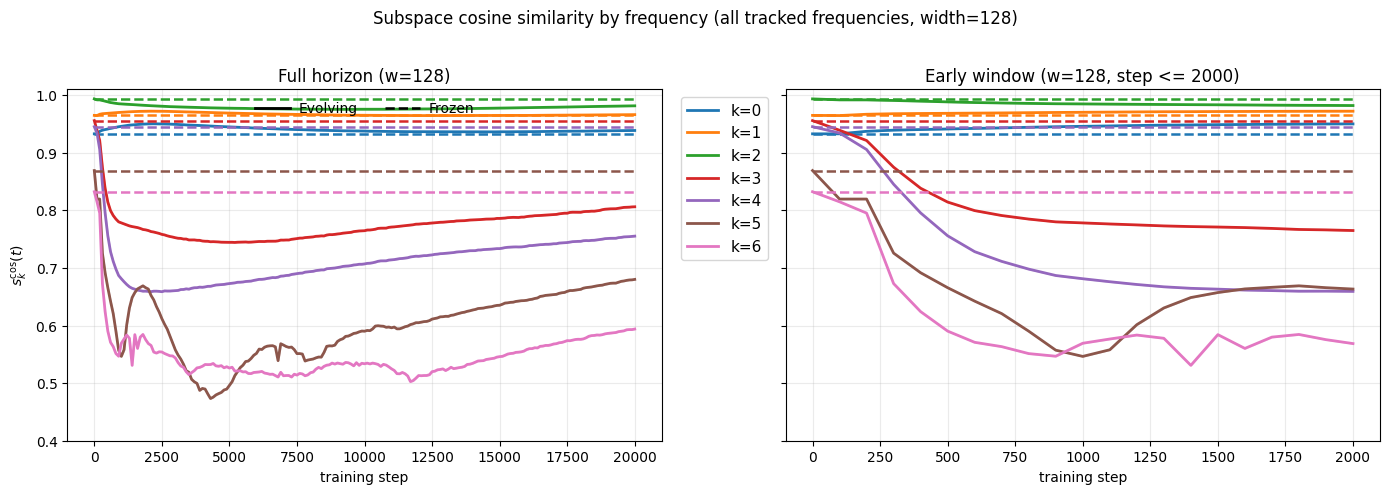

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/rms_cos_alignment_by_freq_allfreq_w256.png


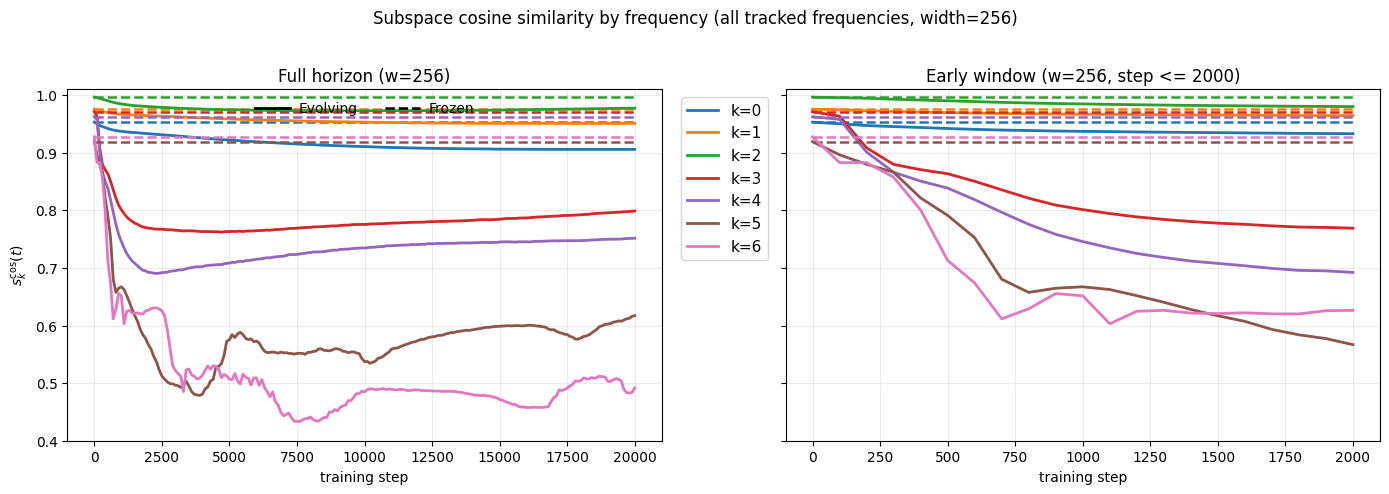

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/rms_cos_alignment_by_freq_allfreq_w512.png


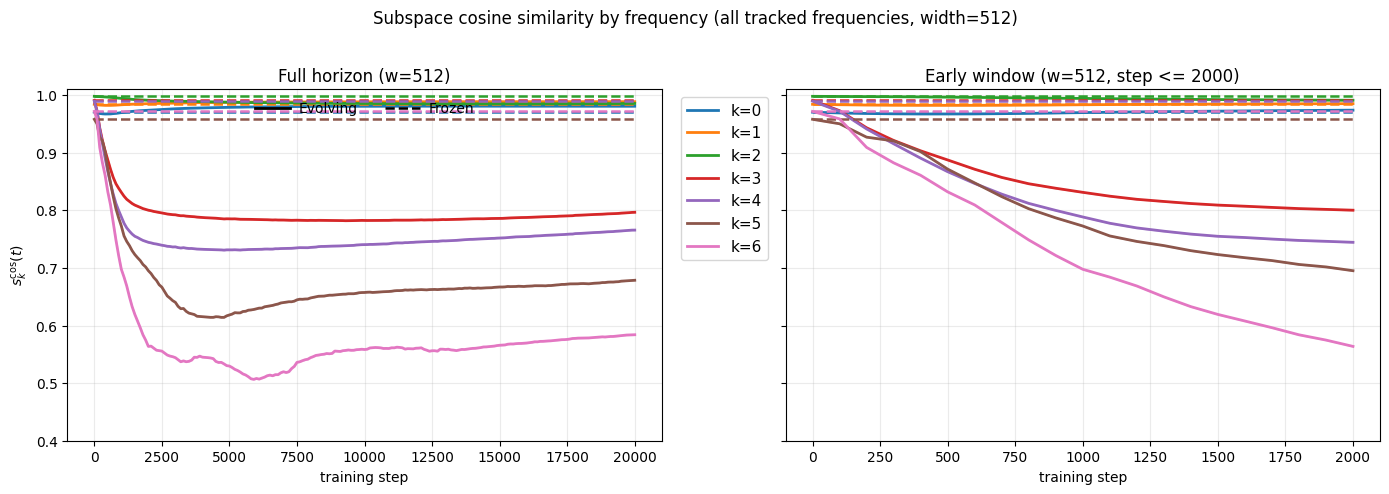

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/rms_cos_alignment_by_freq_allfreq_w1024.png


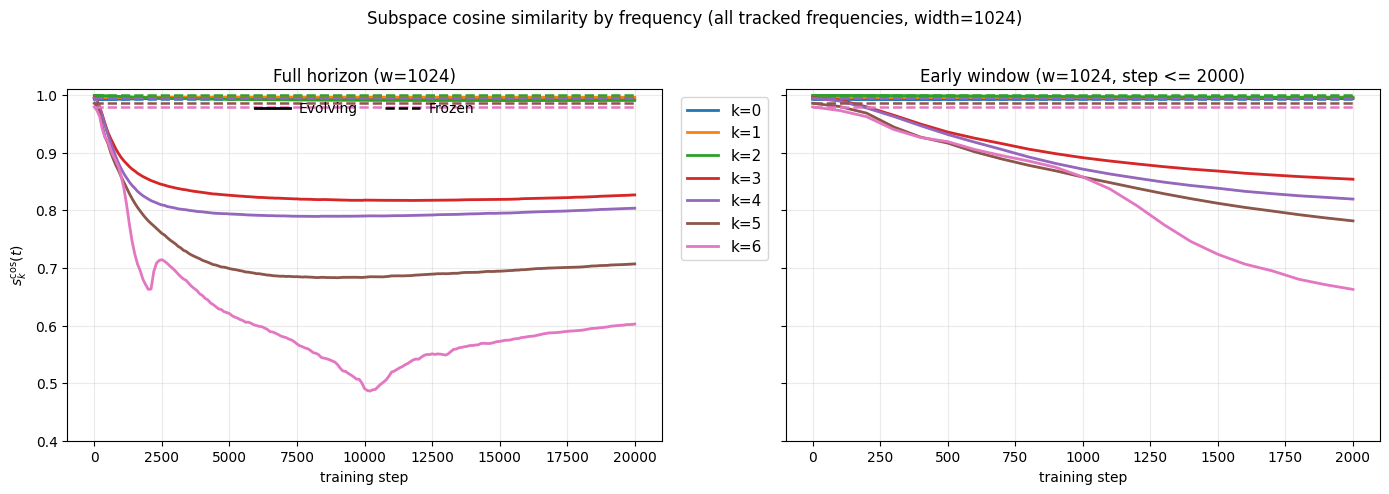

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/rms_cos_alignment_by_freq_no012_w128.png


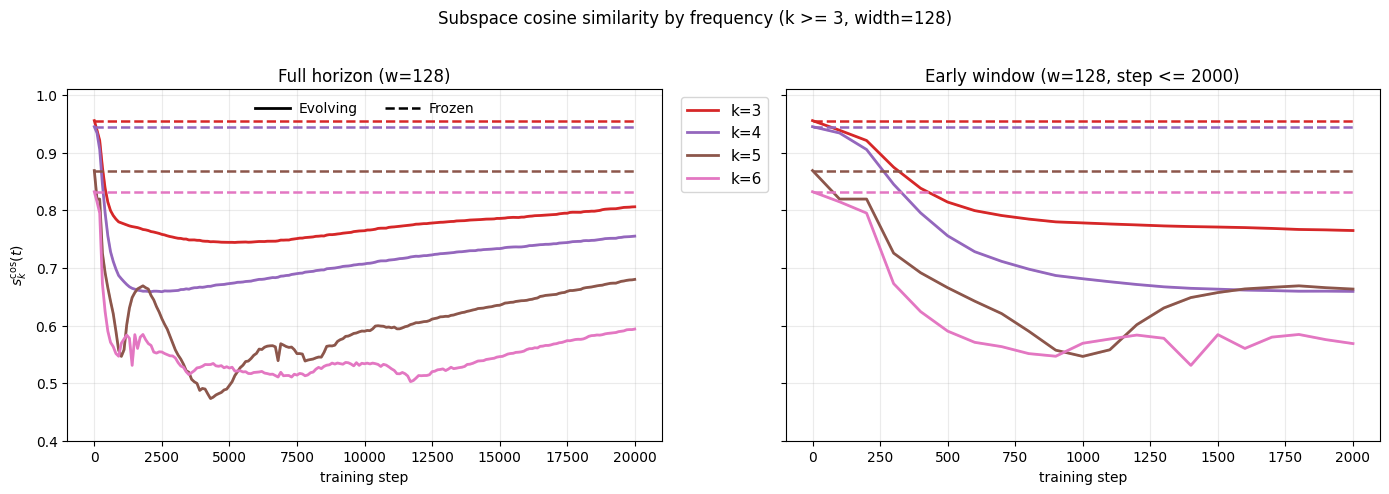

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/rms_cos_alignment_by_freq_no012_w256.png


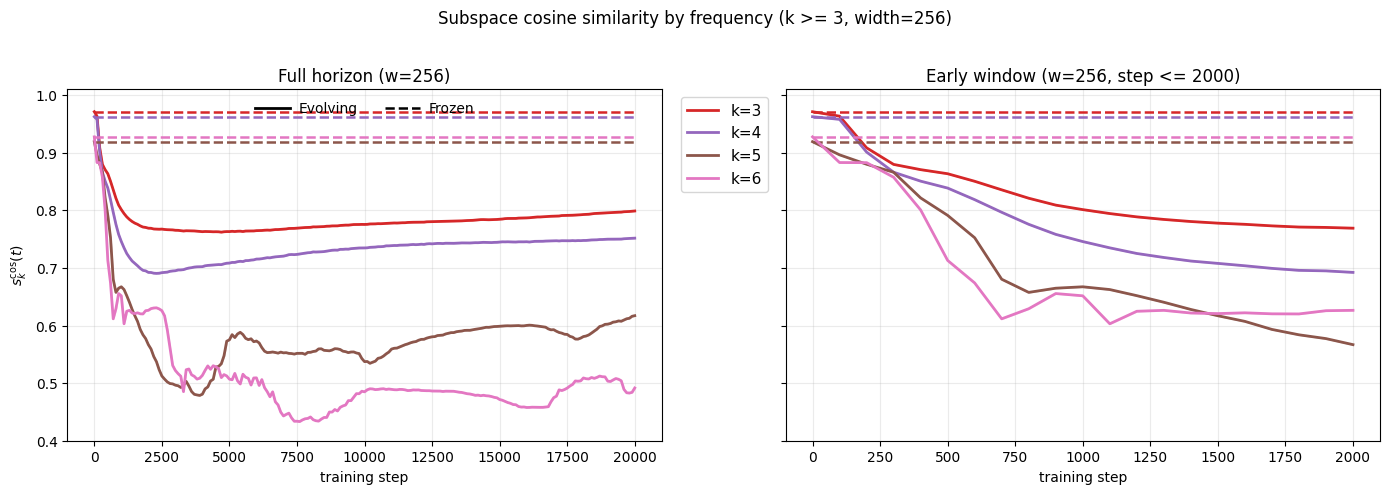

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/rms_cos_alignment_by_freq_no012_w512.png


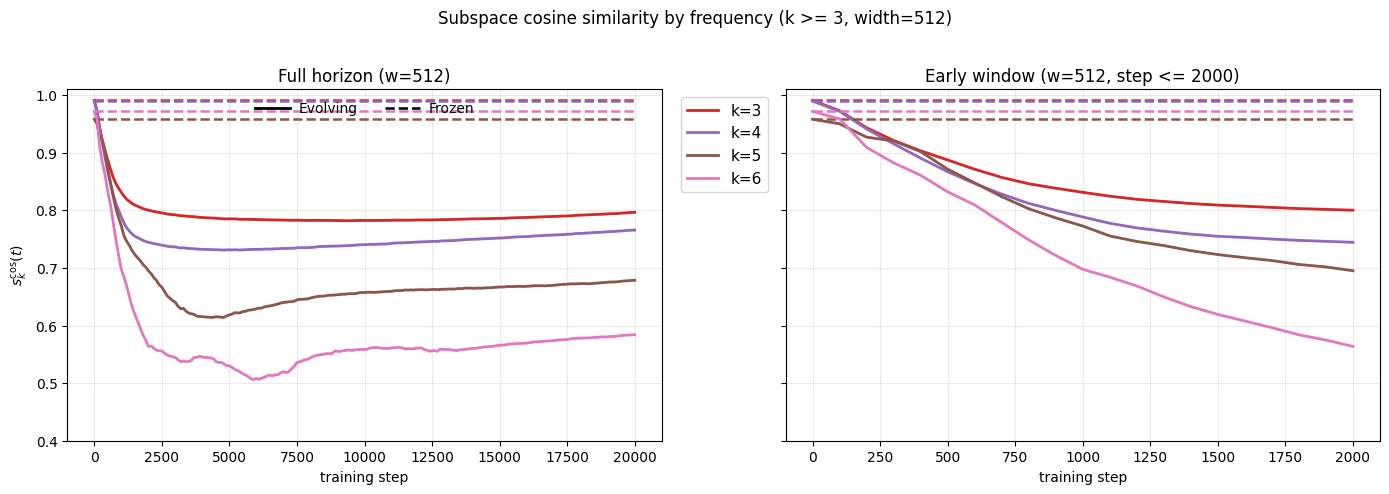

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/rms_cos_alignment_by_freq_no012_w1024.png


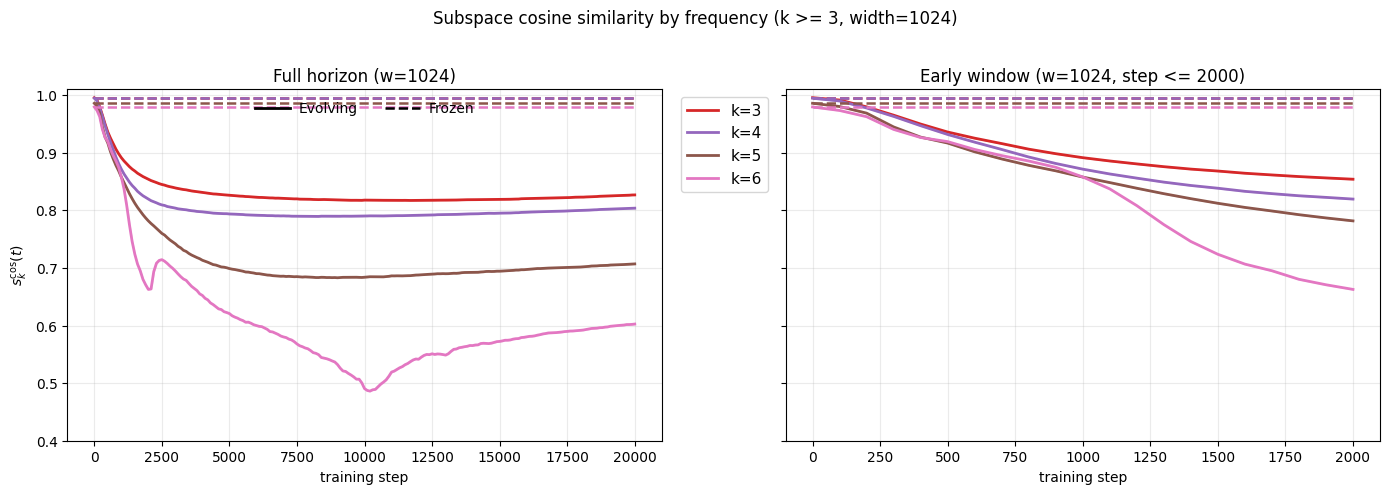

In [67]:
def _plot_rms_alignment_by_width(freq_filter, file_suffix, title_suffix):
    for w in width_keys:
        run_w = run_by_width[w]

        steps_w = np.asarray(run_w["snapshot_steps"], dtype=int)
        freqs_w = np.asarray(run_w["plane_freqs"], dtype=int)
        selected = [int(k) for k in freqs_w if freq_filter(int(k))]
        if len(selected) == 0:
            print(f"Skip width={w}: no selected frequencies for {file_suffix}")
            continue

        angles_f_w = np.asarray(run_w["plane_angles_frozen"], dtype=float)
        angles_e_w = np.asarray(run_w["plane_angles_evolving"], dtype=float)

        score_f_w = np.sqrt(np.nanmean(np.cos(angles_f_w) ** 2, axis=3))
        score_e_w = np.sqrt(np.nanmean(np.cos(angles_e_w) ** 2, axis=3))

        fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
        ax_full, ax_early = axes

        for j, k in enumerate(freqs_w):
            k = int(k)
            if not freq_filter(k):
                continue
            c = freq_color[k]

            mf = np.nanmean(score_f_w[:, :, j], axis=0)
            sf = np.nanstd(score_f_w[:, :, j], axis=0)
            me = np.nanmean(score_e_w[:, :, j], axis=0)
            se = np.nanstd(score_e_w[:, :, j], axis=0)

            ax_full.plot(steps_w, me, linewidth=2.0, color=c, label=f"k={k}")
            ax_full.fill_between(steps_w, np.maximum(me - se, 0.0), np.minimum(me + se, 1.0), alpha=0.16, color=c)
            ax_full.plot(steps_w, mf, '--', linewidth=1.8, color=c)

            mask_w = steps_w <= EARLY_MAX_STEP_STACK
            ax_early.plot(steps_w[mask_w], me[mask_w], linewidth=2.0, color=c, label=f"k={k}")
            ax_early.fill_between(
                steps_w[mask_w],
                np.maximum(me[mask_w] - se[mask_w], 0.0),
                np.minimum(me[mask_w] + se[mask_w], 1.0),
                alpha=0.16,
                color=c,
            )
            ax_early.plot(steps_w[mask_w], mf[mask_w], '--', linewidth=1.8, color=c)

        ax_full.set_title(f"Full horizon (w={w})")
        ax_early.set_title(f"Early window (w={w}, step <= {EARLY_MAX_STEP_STACK})")

        for ax in axes:
            ax.set_xlabel("training step")
            ax.set_ylim(0.4, 1.01)
            ax.grid(True, alpha=0.25)

        ax_full.set_ylabel(r"$s_k^{\mathrm{cos}}(t)$")

        style_elements = [
            Line2D([0], [0], color="black", linestyle="-", lw=2.0, label="Evolving"),
            Line2D([0], [0], color="black", linestyle="--", lw=1.8, label="Frozen"),
        ]
        style_legend = ax_full.legend(
            handles=style_elements,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.0),
            ncol=2,
            fontsize=10,
            frameon=False,
            handlelength=2.5,
            handletextpad=0.6,
        )
        ax_full.add_artist(style_legend)

        color_handles = [
            Line2D([0], [0], color=freq_color[k], linestyle='-', lw=2.0, label=f"k={k}")
            for k in selected
        ]
        ax_full.legend(handles=color_handles, fontsize=11, bbox_to_anchor=(1.02, 1), loc="upper left")

        fig.suptitle(f"Subspace cosine similarity by frequency ({title_suffix}, width={w})", y=1.02)
        fig.tight_layout()

        filename = plot_path / f"rms_cos_alignment_by_freq_{file_suffix}_w{w}.png"
        plt.savefig(filename, bbox_inches="tight")
        print(f"Successfully saved {filename}")
        plt.show()

_plot_rms_alignment_by_width(lambda k: True, file_suffix="allfreq", title_suffix="all tracked frequencies")
_plot_rms_alignment_by_width(lambda k: k >= 3, file_suffix="no012", title_suffix="k >= 3")


Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/spectral_strength_by_freq_allfreq_w128.png


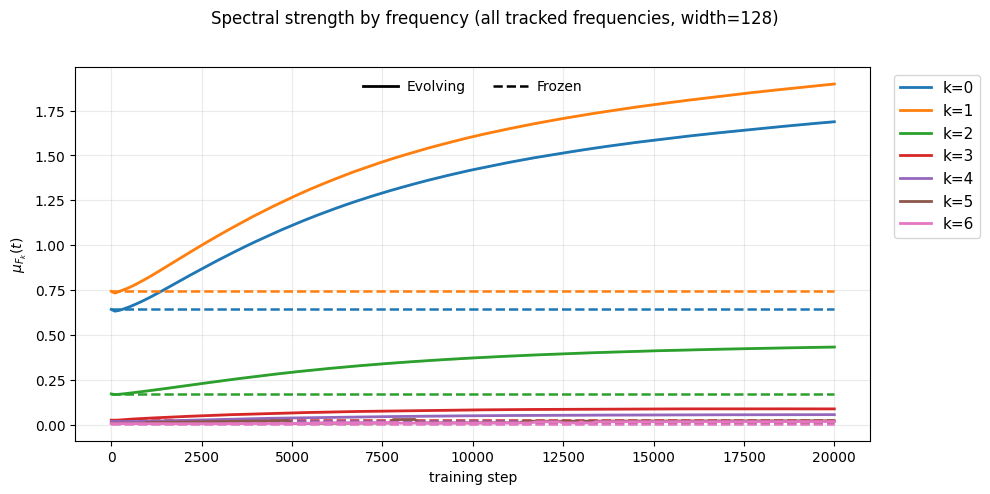

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/spectral_strength_by_freq_allfreq_w256.png


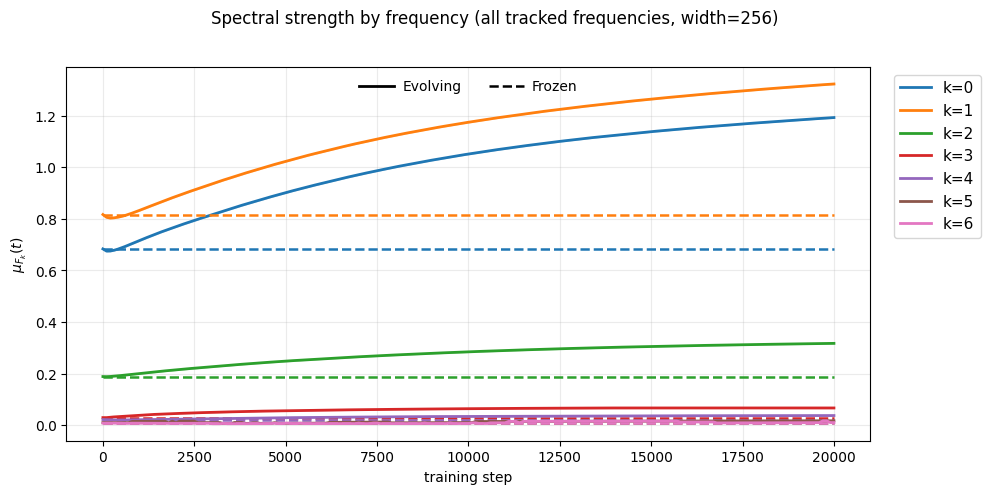

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/spectral_strength_by_freq_allfreq_w512.png


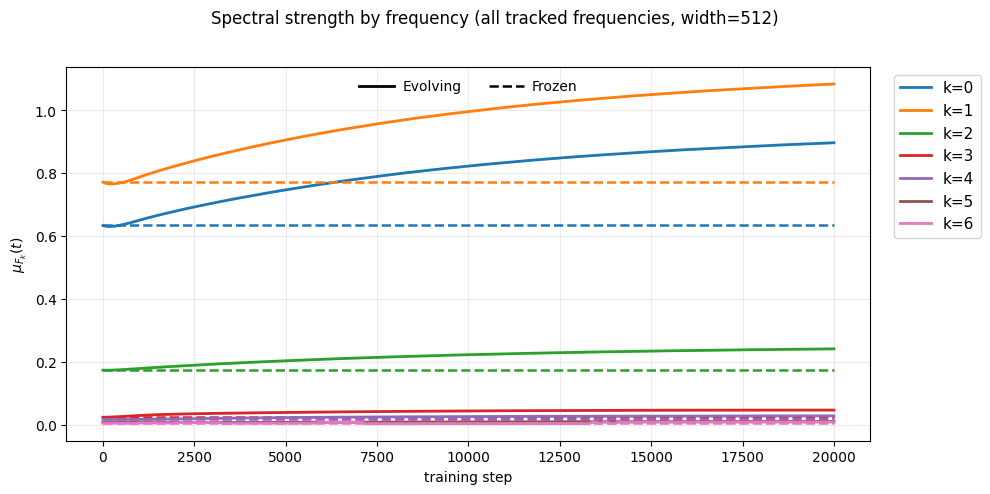

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/spectral_strength_by_freq_allfreq_w1024.png


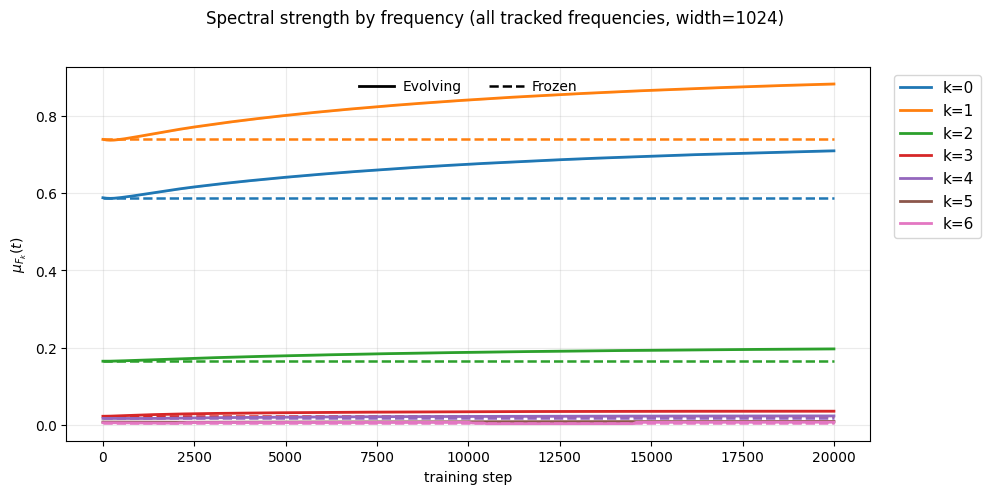

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/spectral_strength_by_freq_no012_w128.png


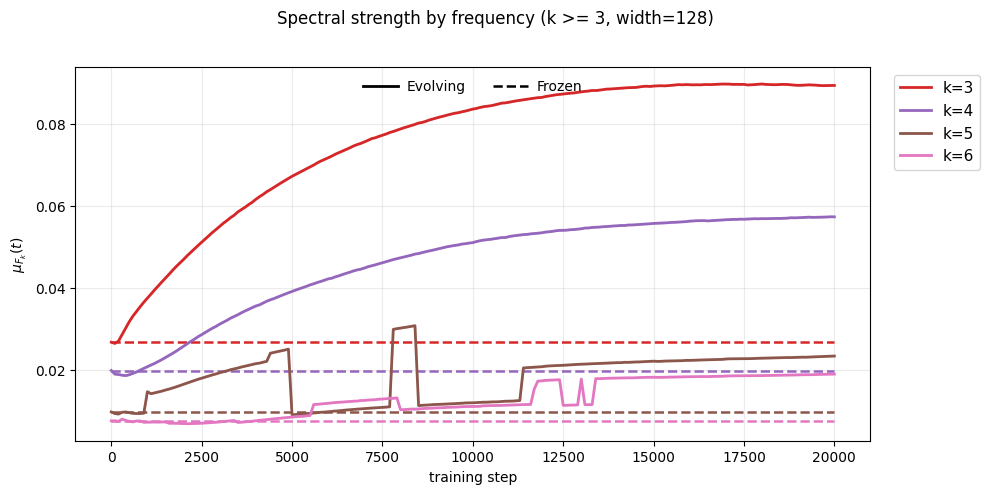

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/spectral_strength_by_freq_no012_w256.png


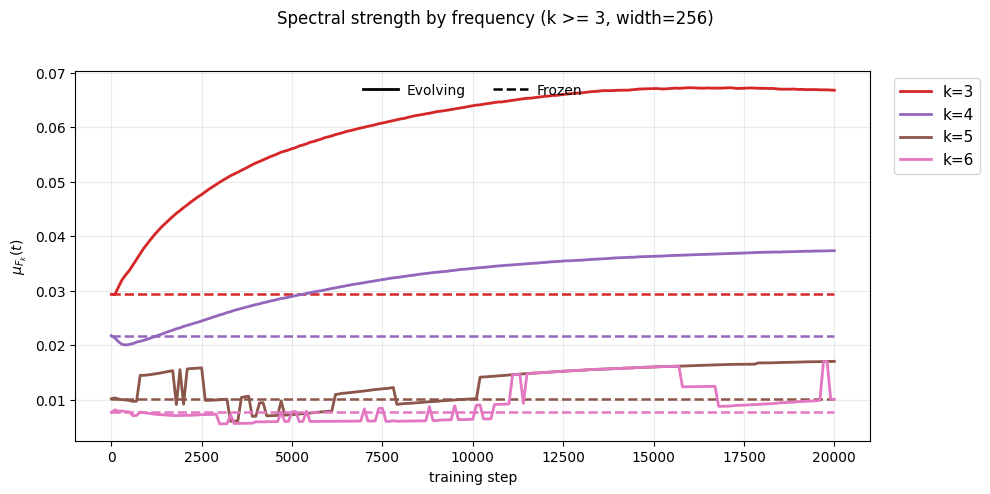

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/spectral_strength_by_freq_no012_w512.png


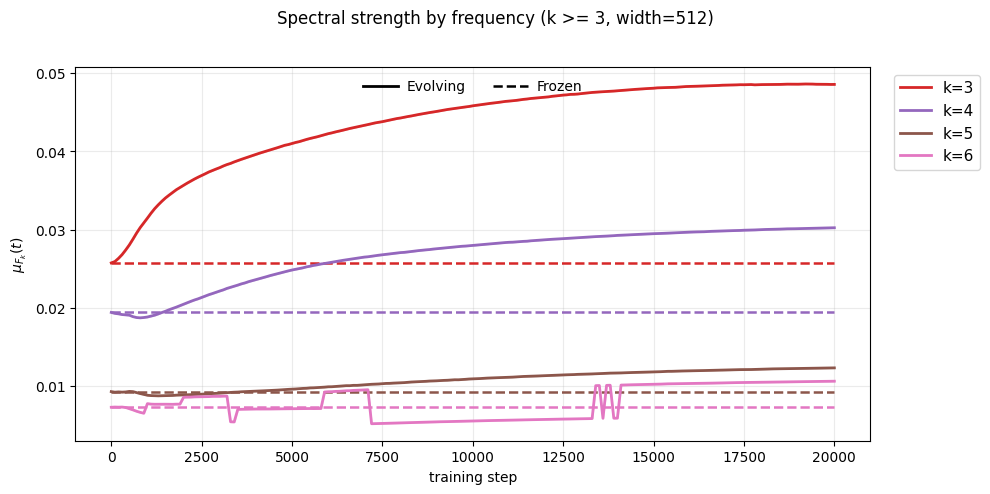

Successfully saved plots/ntk_frozen_vs_evolving_mode_dynamics_k3456_no012_quick_w512/spectral_strength_by_freq_no012_w1024.png


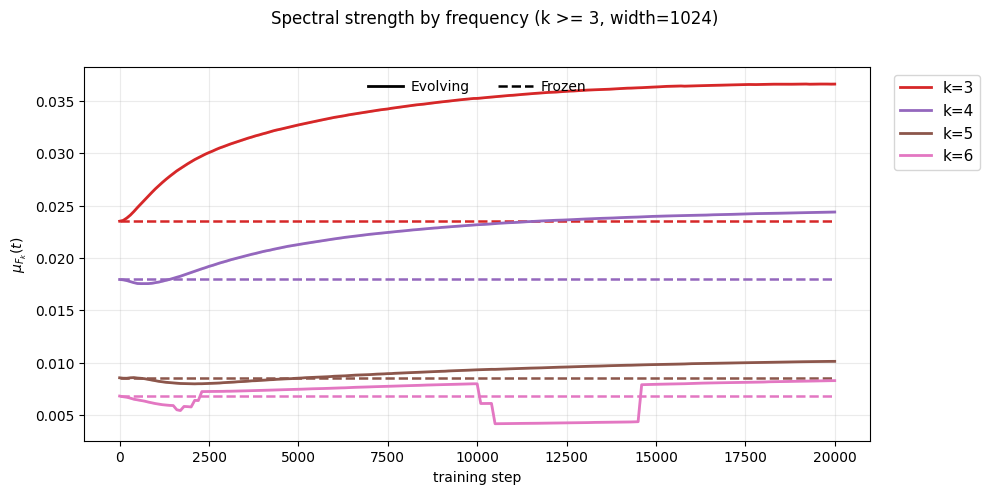

In [68]:
def _plot_spectral_strength_by_width(freq_filter, file_suffix, title_suffix):
    for w in width_keys:
        run_w = run_by_width[w]

        steps_w = np.asarray(run_w["snapshot_steps"], dtype=int)
        freqs_w = np.asarray(run_w["plane_freqs"], dtype=int)
        selected = [int(k) for k in freqs_w if freq_filter(int(k))]
        if len(selected) == 0:
            print(f"Skip width={w}: no selected frequencies for {file_suffix}")
            continue

        eigvals_f_w = np.asarray(run_w["plane_eigvals_frozen"], dtype=float)
        eigvals_e_w = np.asarray(run_w["plane_eigvals_evolving"], dtype=float)

        strength_f_w = np.nansum(eigvals_f_w, axis=3)
        strength_e_w = np.nansum(eigvals_e_w, axis=3)

        fig, ax = plt.subplots(figsize=(10, 4.8))

        for j, k in enumerate(freqs_w):
            k = int(k)
            if not freq_filter(k):
                continue
            c = freq_color[k]

            mf = np.nanmean(strength_f_w[:, :, j], axis=0)
            sf = np.nanstd(strength_f_w[:, :, j], axis=0)
            me = np.nanmean(strength_e_w[:, :, j], axis=0)
            se = np.nanstd(strength_e_w[:, :, j], axis=0)

            ax.plot(steps_w, me, linewidth=2.0, color=c, label=f"k={k}")
            ax.fill_between(steps_w, np.maximum(me - se, 0.0), me + se, alpha=0.16, color=c)
            ax.plot(steps_w, mf, '--', linewidth=1.8, color=c)

        ax.set_xlabel("training step")
        ax.set_ylabel(r"$\mu_{F_k}(t)$")
        ax.grid(True, alpha=0.25)

        style_elements = [
            Line2D([0], [0], color="black", linestyle="-", lw=2.0, label="Evolving"),
            Line2D([0], [0], color="black", linestyle="--", lw=1.8, label="Frozen"),
        ]
        style_legend = ax.legend(
            handles=style_elements,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.0),
            ncol=2,
            fontsize=10,
            frameon=False,
            handlelength=2.5,
            handletextpad=0.6,
        )
        ax.add_artist(style_legend)

        color_handles = [
            Line2D([0], [0], color=freq_color[k], linestyle='-', lw=2.0, label=f"k={k}")
            for k in selected
        ]
        ax.legend(handles=color_handles, fontsize=11, bbox_to_anchor=(1.02, 1), loc="upper left")

        fig.suptitle(f"Spectral strength by frequency ({title_suffix}, width={w})", y=1.02)
        fig.tight_layout()

        filename = plot_path / f"spectral_strength_by_freq_{file_suffix}_w{w}.png"
        plt.savefig(filename, bbox_inches="tight")
        print(f"Successfully saved {filename}")
        plt.show()

_plot_spectral_strength_by_width(lambda k: True, file_suffix="allfreq", title_suffix="all tracked frequencies")
_plot_spectral_strength_by_width(lambda k: k >= 3, file_suffix="no012", title_suffix="k >= 3")
